# Bone marrow (GSE120221) — preprocessing for Decipher

Prepares Oetjen et al. 2018 human bone marrow scRNA-seq so the same object can be trained by
both arms in this repo: `decipher` (native, the untouched control) and `decipher_zx2`
(model5).

**Source.** GEO GSE120221 — Oetjen et al., *JCI Insight* 2018. Bone marrow mononuclear cells
(Ficoll density gradient, **no CD34 enrichment**), 10x Genomics Single Cell 3′ v2, HiSeq3000.
25 samples from 20 healthy donors, ages 24–84.

**Design.** Verified from `GSE120221_series_matrix.txt.gz`: 20 primary samples, one per donor,
plus 5 replicates.

| sample | `!Sample_description` | donor |
|---|---|---|
| `Ck`  | Biological replicate of C1 | C |
| `C2`  | Technical replicate of C1  | C |
| `Sk1` | Biological replicate of S1 | S |
| `S2`  | Technical replicate of S1  | S |
| `Sk2` | Technical replicate of Sk1 | S |

The **technical** pairs (C1/C2, S1/S2, Sk1/Sk2) are a useful reference: same biological
material, re-run, so any batch separation between them is purely technical. They are loaded
and labelled here but excluded from the training object by default (`PRIMARY_ONLY = True`),
because two samples sharing a donor label would inflate within-batch variance for donors C
and S only.

**What `.X` must be.** Raw integer counts, unnormalised and un-logged. Both packages call
`check_adata_has_integer_counts` (`tools/decipher.py:37`) before training, and both apply
`log1p` in `guide()` plus a library-size term in `model()`
(`tools/_decipher/decipher.py`). Running `sc.pp.normalize_total` or `sc.pp.log1p` on `.X`
would fail the gate, and if forced through would log twice.


In [1]:
import gzip, re, sys, tarfile, time
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.io
import scipy.sparse as sp

REPO   = Path("/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods")
DATA   = REPO / "Real Data Analysis" / "Data 1"
TAR    = DATA / "GSE120221_RAW.tar"
SERIES = DATA / "GSE120221_series_matrix.txt.gz"
RAW    = DATA / "raw"                              # per-sample dirs, created below

# ---- knobs -------------------------------------------------------------------
# PRIMARY_ONLY is the one decision to make BEFORE running anything below.
#   True  -> 20 donors, one sample each. The clean patient-as-batch setup.
#   False -> all 25, including the technical pairs C1/C2, S1/S2, Sk1/Sk2. Donors C
#            and S then carry several samples under one label, which inflates their
#            within-batch variance -- but those pairs are the only technical-only
#            reference this data has (see the closing notes).
PRIMARY_ONLY = True
MIN_GENES    = 200     # per cell
MIN_CELLS    = 3       # per gene
MAX_PCT_MT   = 20.0
N_TOP_GENES  = 2000
BATCH_KEY    = "donor"
LEIDEN_RES   = 1.0     # annotation clustering (section 7)
# Measured on this data: ~20 s/epoch for BOTH arms (75,441 cells -> 1,060 minibatches at
# batch_size=64). DecipherConfig defaults to n_epochs=1000, i.e. a 5.5 HOUR worst case per
# arm if early stopping never fires. Cap it explicitly. 200 epochs ~= 67 min per arm.
N_EPOCHS     = 200
KEEP_RAW     = False   # stash the full gene set in .raw; adds ~1 GB to the h5ad
# ------------------------------------------------------------------------------

# Filename tracks PRIMARY_ONLY so the two variants cannot overwrite each other.
OUT = DATA / f"bone_marrow_decipher_{'primary20' if PRIMARY_ONLY else 'all25'}.h5ad"

sc.settings.verbosity = 1
print("tar   :", TAR.exists(), f"{TAR.stat().st_size / 1e6:.0f} MB")
print("series:", SERIES.exists())
print("out   :", OUT.name)

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


tar   : True 315 MB
series: True
out   : bone_marrow_decipher_primary20.h5ad


## 1. Unpack

The archive is flat — 75 entries named `GSM<id>_{barcodes,genes,matrix}_<SAMPLE>.<ext>.gz`.
Reorganise into one directory per sample.

In [2]:
FNAME = re.compile(r"^(GSM\d+)_(barcodes|genes|matrix)_(.+?)\.(tsv|mtx)\.gz$")

if not RAW.exists():
    RAW.mkdir(parents=True)
    n = 0
    with tarfile.open(TAR) as tf:
        for m in tf.getmembers():
            hit = FNAME.match(Path(m.name).name)
            if hit is None:
                print("skipping unrecognised entry:", m.name)
                continue
            _gsm, kind, sample, ext = hit.groups()
            dest = RAW / sample
            dest.mkdir(exist_ok=True)
            with tf.extractfile(m) as src, open(dest / f"{kind}.{ext}.gz", "wb") as out:
                out.write(src.read())
            n += 1
    print(f"extracted {n} entries")
else:
    print("already extracted:", RAW)

samples = sorted(p.name for p in RAW.iterdir() if p.is_dir())
print(f"{len(samples)} samples:", " ".join(samples))

already extracted: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Real Data Analysis/Data 1/raw
25 samples: A B C1 C2 Ck E F G H J K L M N O P Q R S1 S2 Sk1 Sk2 T U W


## 2. Sample metadata

The counts files carry only the GSM number and the letter suffix. Ages and the replicate
labels exist **only** in the series matrix, so parse it here.

In [3]:
def parse_series_matrix(path):
    """Sample-level metadata from a GEO series matrix file.

    One row per sample, indexed by the short name taken from !Sample_title
    ("Bone marrow C1" -> "C1").
    """
    fields = {}
    with gzip.open(path, "rt") as f:
        for line in f:
            if not line.startswith("!Sample_"):
                continue
            key, *vals = line.rstrip("\n").split("\t")
            fields.setdefault(key, []).append([v.strip('"') for v in vals])

    out = pd.DataFrame({
        "sample": [t.replace("Bone marrow ", "") for t in fields["!Sample_title"][0]],
        "gsm": fields["!Sample_geo_accession"][0],
        "description": fields["!Sample_description"][0],
    })
    # !Sample_characteristics_ch1 appears once per characteristic; pick out the age row.
    for row in fields["!Sample_characteristics_ch1"]:
        if row and row[0].startswith("age:"):
            out["age"] = [int(v.split(":")[1].split()[0]) for v in row]
    return out.set_index("sample")


meta = parse_series_matrix(SERIES)

# donor = leading letter of the sample name: C1/Ck/C2 -> C, S1/Sk1/S2/Sk2 -> S, K -> K
meta["donor"] = meta.index.str[0]
meta["replicate_type"] = np.select(
    [meta["description"].str.startswith("Technical"),
     meta["description"].str.startswith("Biological")],
    ["technical", "biological"], default="primary")
meta["replicate_of"] = meta["description"].str.extract(r"replicate of (\S+)")[0].fillna("")
meta["is_primary"] = meta["replicate_type"] == "primary"

missing = set(samples) ^ set(meta.index)
assert not missing, f"tar and series matrix disagree on samples: {sorted(missing)}"

print(f"{len(meta)} samples | {meta['donor'].nunique()} donors | "
      f"{meta['is_primary'].sum()} primary")
meta[["gsm", "donor", "age", "replicate_type", "replicate_of"]]

25 samples | 20 donors | 20 primary


,gsm,donor,age,replicate_type,replicate_of
sample,,,,,
A,GSM3396161,A,59,primary,
B,GSM3396162,B,47,primary,
C1,GSM3396163,C,60,primary,
Ck,GSM3396164,C,59,biological,C1
C2,GSM3396165,C,60,technical,C1
E,GSM3396166,E,30,primary,
F,GSM3396167,F,41,primary,
G,GSM3396168,G,58,primary,
H,GSM3396169,H,50,primary,


## 3. Load the counts

`sc.read_10x_mtx` **cannot read this layout.** It supports CellRanger v2 *uncompressed*
(`genes.tsv`) or v3 *gzipped* (`features.tsv.gz`, three columns). These files are v2
*gzipped* — `genes.tsv.gz` with two columns — which falls between the two cases
(`scanpy/readwrite.py`: `is_legacy = (path / "genes.tsv").is_file()`, then
`suffix = "" if is_legacy else ".gz"`). Renaming to `features.tsv.gz` does not help either:
the v3 branch reads a third column that these files do not have.

So read them directly. Verified on sample `A`: 2,994 cells × 33,694 genes, integer-valued,
~0.3 s.

In [4]:
def read_sample(d):
    """One CellRanger v2 gzipped sample directory -> AnnData (cells x genes)."""
    with gzip.open(d / "matrix.mtx.gz", "rb") as f:
        M = scipy.io.mmread(f)                      # (genes, cells)
    genes = pd.read_csv(d / "genes.tsv.gz", header=None, sep="\t")
    bcs   = pd.read_csv(d / "barcodes.tsv.gz", header=None, sep="\t")
    a = ad.AnnData(
        X=sp.csr_matrix(M.T, dtype=np.float32),     # -> (cells, genes)
        obs=pd.DataFrame(index=bcs[0].astype(str).values),
        var=pd.DataFrame({"gene_ids": genes[0].values},
                         index=pd.Index(genes[1].astype(str).values)),
    )
    a.var_names_make_unique()
    return a


t0 = time.time()
parts = {}
for s in samples:
    parts[s] = read_sample(RAW / s)
    print(f"  {s:4s} {parts[s].shape[0]:>6,d} cells x {parts[s].shape[1]:,d} genes")
print(f"\nread {len(parts)} samples in {time.time() - t0:.0f}s")

adata = ad.concat(parts, label="sample", index_unique="-", merge="same")
adata.obs["sample"] = adata.obs["sample"].astype("category")
print("concatenated:", adata.shape)

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  A     2,994 cells x 33,694 genes


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  B     3,293 cells x 33,694 genes


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

  T     4,293 cells x 33,694 genes


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  U     4,118 cells x 33,694 genes


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  W     3,643 cells x 33,694 genes

read 25 samples in 7s
concatenated: (90653, 33694)


## 4. Attach metadata

In [5]:
for col in ["gsm", "donor", "age", "replicate_type", "replicate_of", "is_primary"]:
    adata.obs[col] = adata.obs["sample"].map(meta[col]).values

for col in ["donor", "replicate_type"]:
    adata.obs[col] = adata.obs[col].astype("category")

print("samples per replicate_type:")
print(adata.obs.groupby("replicate_type", observed=True)["sample"].nunique(), "\n")
print("cells per donor:")
print(adata.obs["donor"].value_counts().sort_index())

samples per replicate_type:
replicate_type
biological     2
primary       20
technical      3
Name: sample, dtype: int64 

cells per donor:
donor
A     2994
B     3293
C     7744
E     3939
F     3746
G     4283
H     4516
J     3446
K     7247
L     4548
M     3964
N     4522
O     5013
P     3383
Q     1700
R     3593
S    10668
T     4293
U     4118
W     3643
Name: count, dtype: int64


## 5. Quality control

Neither package filters anything — `decipher_train` goes straight from the AnnData to a
dataloader. All filtering has to happen here.

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True,
                           log1p=False, percent_top=None)

before = adata.shape
adata = adata[adata.obs["pct_counts_mt"] < MAX_PCT_MT].copy()
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
print(f"{before} -> {adata.shape}")

(90653, 33694) -> (87287, 23478)


In [7]:
if PRIMARY_ONLY:
    adata = adata[adata.obs["is_primary"]].copy()
    for col in ["donor", "sample", "replicate_type"]:
        adata.obs[col] = adata.obs[col].cat.remove_unused_categories()
    print("primary only:", adata.shape)

n_batches = adata.obs[BATCH_KEY].cat.categories.size
print(f"{BATCH_KEY!r} -> n_batches = {n_batches}")
assert adata.obs[BATCH_KEY].isna().sum() == 0, "NaN batch labels produce code -1 and will raise"

primary only: (75441, 23478)
'donor' -> n_batches = 20


## 6. Gene selection

`flavor="seurat_v3"` is the one flavour that expects **raw counts**, so `.X` stays untouched.
(`scikit-misc` is required and is installed in this `.venv`.)

Subsetting is not optional. `make_data_loader_from_adata`
(`tools/_decipher/data.py:92`) does `torch.FloatTensor(get_dense_X(adata))` — the whole
matrix is materialised dense, float32, in RAM.

In [8]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3",
                            n_top_genes=N_TOP_GENES, batch_key=BATCH_KEY)

if KEEP_RAW:
    adata.raw = adata

adata = adata[:, adata.var["highly_variable"]].copy()
print("after HVG:", adata.shape)

n_cells, n_genes = adata.shape
print(f"\ndense training tensor: {n_cells:,d} x {n_genes:,d} x 4 B = "
      f"{n_cells * n_genes * 4 / 1e9:.2f} GB")
print("(decipher_train builds a train and a validation loader, so peak is higher)")

after HVG: (75441, 2000)

dense training tensor: 75,441 x 2,000 x 4 B = 0.60 GB
(decipher_train builds a train and a validation loader, so peak is higher)


## 7. Annotate — run this before training, not after

Two things depend on having a biological label, and neither needs Decipher:

1. **Is there enough erythroid signal to bother?** This is whole BMMC with no CD34
   enrichment, so progenitors are a minority. Worth knowing before a long training run.
2. **The integration metrics need a biological label.** `graph_connectivity` and
   `silhouette_batch` score how well biology survives correction. GSE120221 ships no cell
   type labels, so they have to be derived here.

Measured on this data (20 primary donors, 2000 HVGs, `LEIDEN_RES = 1.0`): **35 clusters,
and 22.6% of cells — 17,075 of 75,441 — score as erythroid.** All ten erythroid markers
below survive HVG selection. That is ample for trajectory work.

Clustering needs normalised, scaled data; Decipher needs raw counts. So this runs on a
**copy** and only the resulting labels are written back — `adata.X` is never touched.

In [9]:
tmp = adata.copy()
sc.pp.normalize_total(tmp, target_sum=1e4)      # on the COPY only
sc.pp.log1p(tmp)
sc.pp.scale(tmp, max_value=10)
sc.tl.pca(tmp, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(tmp, n_neighbors=15, random_state=0)
sc.tl.leiden(tmp, resolution=LEIDEN_RES, key_added="leiden", random_state=0,
             flavor="igraph", n_iterations=2)
print(tmp.obs["leiden"].cat.categories.size, "clusters")

MARKERS = {
    "erythroid":  ["HBB", "HBD", "HBA1", "HBA2", "GATA1", "KLF1", "AHSP", "ALAS2",
                   "CA1", "GYPA"],
    "progenitor": ["CD34", "GATA2", "MPO", "AVP"],
    "T_NK":       ["CD3D", "CD3E", "IL7R", "NKG7", "GNLY"],
    "B":          ["MS4A1", "CD79A", "CD79B", "IGHM"],
    "myeloid":    ["LYZ", "S100A8", "S100A9", "CST3", "FCN1"],
}
for name, genes in MARKERS.items():
    present = [g for g in genes if g in tmp.var_names]
    missing = [g for g in genes if g not in tmp.var_names]
    if missing:
        print(f"  {name}: {len(missing)} marker(s) lost to HVG selection: {missing}")
    sc.tl.score_genes(tmp, present, score_name=f"score_{name}")

score_cols = [f"score_{k}" for k in MARKERS]
per_cluster = tmp.obs.groupby("leiden", observed=True)[score_cols].mean()
winner = per_cluster.idxmax(axis=1).str.replace("score_", "", regex=False)

# write labels back onto the raw-count object
adata.obs["leiden"] = tmp.obs["leiden"].values
adata.obs["cell_class"] = pd.Categorical(adata.obs["leiden"].map(winner))
for c in score_cols:
    adata.obs[c] = tmp.obs[c].values
del tmp

35 clusters
  T_NK: 2 marker(s) lost to HVG selection: ['CD3D', 'CD3E']


In [10]:
n_ery = int((adata.obs["cell_class"] == "erythroid").sum())
print(f"erythroid: {n_ery:,d} / {adata.n_obs:,d} cells = "
      f"{100 * n_ery / adata.n_obs:.1f}%\n")

summary = adata.obs["cell_class"].value_counts().to_frame("cells")
summary["pct"] = (100 * summary["cells"] / adata.n_obs).round(1)
print(summary)

# Does every batch contain the biology? If a donor has no erythroid cells, "batch removed,
# trajectory preserved" is not well posed for that donor.
ct = pd.crosstab(adata.obs[BATCH_KEY], adata.obs["cell_class"])
print(f"\ndonors with zero erythroid cells: "
      f"{list(ct.index[ct.get('erythroid', 0) == 0]) or 'none'}")

erythroid: 20,399 / 75,441 cells = 27.0%

            cells   pct
cell_class             
T_NK        36367  48.2
erythroid   20399  27.0
myeloid      9592  12.7
B            5519   7.3
progenitor   3564   4.7

donors with zero erythroid cells: none


## 8. Check the gate both packages call

This is the check that rejected the spatial NUT file: its `.X` and even its
`layers["counts"]` are non-integer.

In [11]:
sys.path.insert(0, str(REPO / "model5"))   # model5 is not pip-installed; native is
from decipher.tools.decipher import check_adata_has_integer_counts as gate_native
from decipher_zx2.tools.decipher import check_adata_has_integer_counts as gate_zx2

for name, gate in [("decipher (native)", gate_native), ("decipher_zx2 (model5)", gate_zx2)]:
    try:
        gate(adata)
        print(f"{name:24s} integer-counts gate: PASS")
    except ValueError as e:
        print(f"{name:24s} integer-counts gate: FAIL -> {e}")

decipher (native)        integer-counts gate: PASS
decipher_zx2 (model5)    integer-counts gate: PASS


In [12]:
adata.write_h5ad(OUT, compression="gzip")
print("wrote", OUT)
print(f"{OUT.stat().st_size / 1e6:.0f} MB")
adata

... storing 'replicate_of' as categorical


wrote /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Real Data Analysis/Data 1/bone_marrow_decipher_primary20.h5ad
37 MB


AnnData object with n_obs × n_vars = 75441 × 2000
    obs: 'sample', 'gsm', 'donor', 'age', 'replicate_type', 'replicate_of', 'is_primary', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_class', 'score_erythroid', 'score_progenitor', 'score_T_NK', 'score_B', 'score_myeloid'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'

## 9. Training

Reload the object fresh for each arm — `decipher_train` writes into `obs`, `obsm` and `uns`,
so the two runs would contaminate each other otherwise.

The call signatures differ, and this is the whole point of the control arm: native
`decipher_train` has **no `batch_key` parameter** and no `n_batches` field on its config. It
ignores `obs["donor"]` entirely. Passing `batch_key=` to it raises `TypeError`.

`plot_every_k_epochs=-2` disables the every-5-epochs plot that `decipher_train` turns on by
default inside a notebook.

**`plot_kwargs={"color": [...]}` is required, and the list brackets matter.** `decipher_train`
ends with an unconditional `plot_decipher_v(adata, basis="decipher_v", **plot_kwargs)`. In the
forked packages `plot/decipher.py` renamed `color` to `color_list` but **line 189 still reads
`len(color)`**:

```python
if color is None or isinstance(color, str):   # L146-149
    color_list = [color]
else:
    color_list = color
...
if i // ncols == (len(color) - 1) // ncols:   # L189  <- still `color`
```

So omitting `plot_kwargs` leaves `color = None` and raises
`TypeError: object of type 'NoneType' has no len()` — *after* training finishes and the
embeddings are written, so the run is wasted. Passing a bare string is worse than it looks:
`len("donor")` is 5, which silently mislabels the axes instead of crashing. That is why the
simulated sweeps never hit this — `train_and_compute_rho_r2` always passes
`plot_kwargs={"color": "batch"}`, and `len("batch")` is 5.

Native `decipher` is unaffected — it rebinds `color` itself at L129-130. The bug is in all
seven forks (`model1-add`, `model2-add`, `model3-add`, `model4`, `model5`, `model6`,
`decipher_models`).

> **Do not "Run All" from here.** Measured on this data, both arms take **~20 s/epoch**
> (75,441 cells → 1,060 minibatches). At the `DecipherConfig` default of `n_epochs=1000`
> that is up to **5.5 hours per arm** if early stopping never fires. `N_EPOCHS` in cell 1
> caps it at 200 (~67 min per arm). Run the two cells below deliberately, one at a time.

Epoch 18 (batch 1060/1060) | | train elbo: 10017747430149.91 (last epoch: 623678271194509.62) | val ll: 1312244848357036032.00:   9%|▉         | 18/200 [06:52<1:09:31, 22.92s/it]2026-09-18 09:30:40,828 | INFO : Early stopping has been triggered.
2026-09-18 09:30:41,153 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-09-18 09:30:41,153 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-09-18 09:30:41,158 | INFO : Saving decipher model with run_id 2026-09-18-09-30-41-brute-force-gold-polytope.


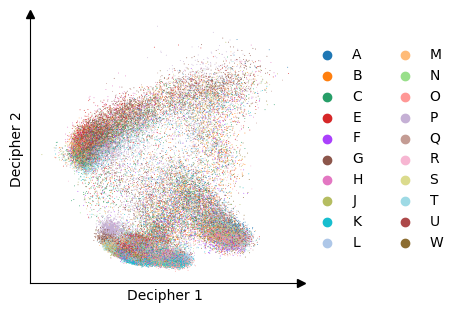

In [13]:
import decipher as dc_native

adata_native = sc.read_h5ad(OUT)
cfg_native = dc_native.tl.DecipherConfig(
    dim_z=10, beta=0.1, learning_rate=1e-3, seed=0, n_epochs=N_EPOCHS,
)

model_native, val_native = dc_native.tl.decipher_train(
    adata_native, cfg_native,
    plot_every_k_epochs=-2,
    plot_kwargs={"color": [BATCH_KEY]},
)
adata_native.write_h5ad(OUT.with_name(OUT.stem + "_trained_native.h5ad"))

In [14]:
import decipher_zx2 as dc_zx2

adata_zx2 = sc.read_h5ad(OUT)
cfg_zx2 = dc_zx2.tl.DecipherConfig(
    dim_z=10, beta=0.1, learning_rate=1e-3, seed=0, n_epochs=N_EPOCHS,
)

model_zx2, val_zx2 = dc_zx2.tl.decipher_train(
    adata_zx2, cfg_zx2,
    batch_key=BATCH_KEY,
    plot_every_k_epochs=-2,
    plot_kwargs={"color": [BATCH_KEY]},   # list, not a bare string -- see above
)
print("n_batches:", model_zx2.config.n_batches, "| batch_key:", model_zx2.config.batch_key)
print("obsm:", list(adata_zx2.obsm))
adata_zx2.write_h5ad(OUT.with_name(OUT.stem + "_trained_zx2.h5ad"))

Epoch 14 (batch 1060/1060) | | train elbo: 579.10 (last epoch: 578.31) | val ll: 592.64:   7%|▋         | 14/200 [05:38<1:15:00, 24.20s/it]2026-09-18 09:36:23,791 | INFO : Early stopping has been triggered.
2026-09-18 09:36:28,102 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-09-18 09:36:28,105 | INFO : Added `.obsm['decipher_z']`: the Decipher z space (batch-corrected).
2026-09-18 09:36:28,105 | INFO : Added `.obsm['decipher_z_raw']`: the Decipher z space (batch effect included).
2026-09-18 09:36:28,106 | INFO : Saving decipher model with run_id 2026-09-18-09-36-28-uniform-cerulean-ketchup.


n_batches: 20 | batch_key: donor
obsm: ['decipher_v', 'decipher_z', 'decipher_z_raw']


## 10. Compare the arms — v, z and x space

The 9.9 equivalent of this section. **These cells go after *both* training cells, not between
them** — `decipher_zx2` does not overwrite the native result. Verified on this data:

```
after BOTH runs:
  native obsm : ['decipher_v', 'decipher_z']
  zx2    obsm : ['decipher_v', 'decipher_z', 'decipher_z_raw']
  same object?  False        <- separate variables
  v identical?  False        <- separate fits
  native run_id: ...-prepared-teal-electric
  zx2    run_id: ...-grilled-coal-string     <- no model-file collision
  X untouched?  True
```

Two consequences of that last line. **X space is identical for both arms**, because training
never modifies `adata.X` — so it is computed once below rather than per arm the way 9.9 did
it. And each object must be loaded with **its own** package if you reload a model later:
native's `uns["decipher"]["config"]` has no `n_batches`/`batch_key` fields, so
`dc_zx2.tl.decipher_load_model(adata_native)` would fail.

Three differences from 9.9, all forced by this being real data:

- `latent_t` does not exist. `cell_class` from section 7 replaces it as the biological label.
- `decipher_time` is not shown. It needs `trajectories`, which needs a `TConfig` with marker
  genes and a start/end cluster — a separate design step, not a plot.
- The `counts_nobatch` ceiling does not exist. The X-space row below is the "as given"
  reference instead: how separated the donors are before any model touches them.

Measured cost at 75,441 cells: X-space PCA well under a minute, and the z-space UMAP roughly
2–4 minutes per arm. `silhouette_score` is O(n²), so it is sampled — `SIL_SAMPLE` cells.

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

SIL_SAMPLE = 5000     # silhouette_score is O(n^2); sample instead of using all cells

TRAINED = {
    "Base Decipher": OUT.with_name(OUT.stem + "_trained_native.h5ad"),
    "Decipher-ZX2":  OUT.with_name(OUT.stem + "_trained_zx2.h5ad"),
}
arms = {k: sc.read_h5ad(p) for k, p in TRAINED.items()}
for k, a in arms.items():
    print(f"{k:16s} {a.shape}  obsm={list(a.obsm)}")

batch_codes = next(iter(arms.values())).obs[BATCH_KEY].cat.codes.to_numpy()

Base Decipher    (75441, 2000)  obsm=['decipher_v', 'decipher_z']
Decipher-ZX2     (75441, 2000)  obsm=['decipher_v', 'decipher_z', 'decipher_z_raw']


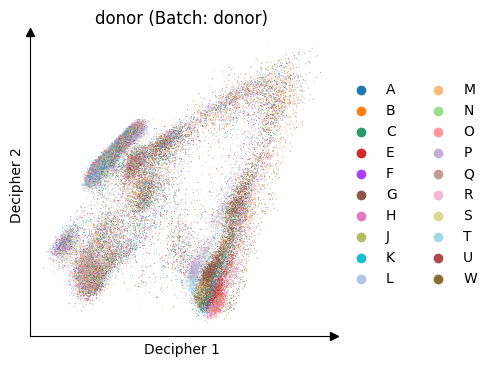

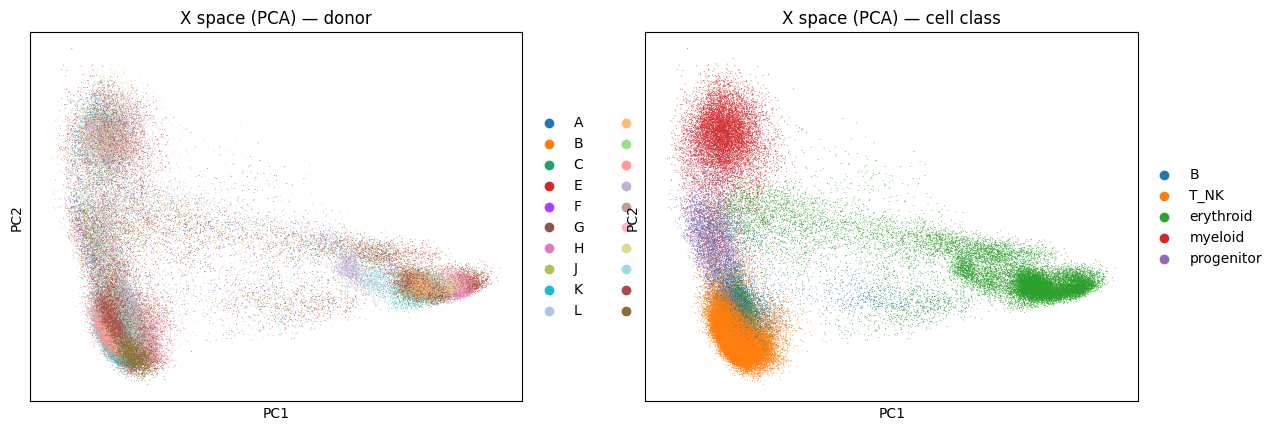

In [16]:
# X space. Identical for both arms -- training never modifies adata.X -- so compute once.
# PCA needs normalised data, and .X is raw counts, so this runs on a copy.
xs = next(iter(arms.values())).copy()
sc.pp.normalize_total(xs, target_sum=1e4)
sc.pp.log1p(xs)
sc.pp.pca(xs, n_comps=50, svd_solver="arpack")

sc.pl.embedding(xs, basis="pca", color=[BATCH_KEY, "cell_class"], ncols=2,
                title=["X space (PCA) — donor", "X space (PCA) — cell class"])

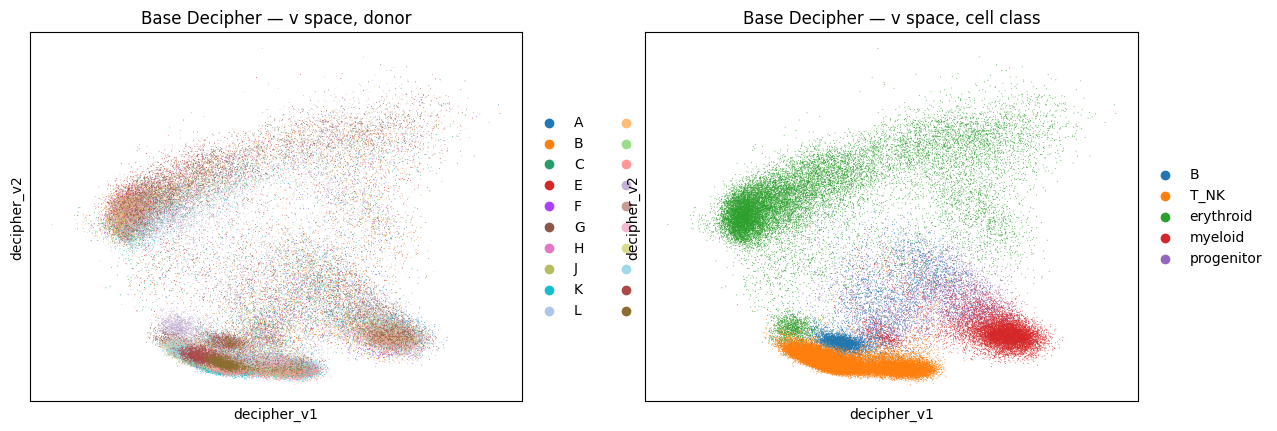

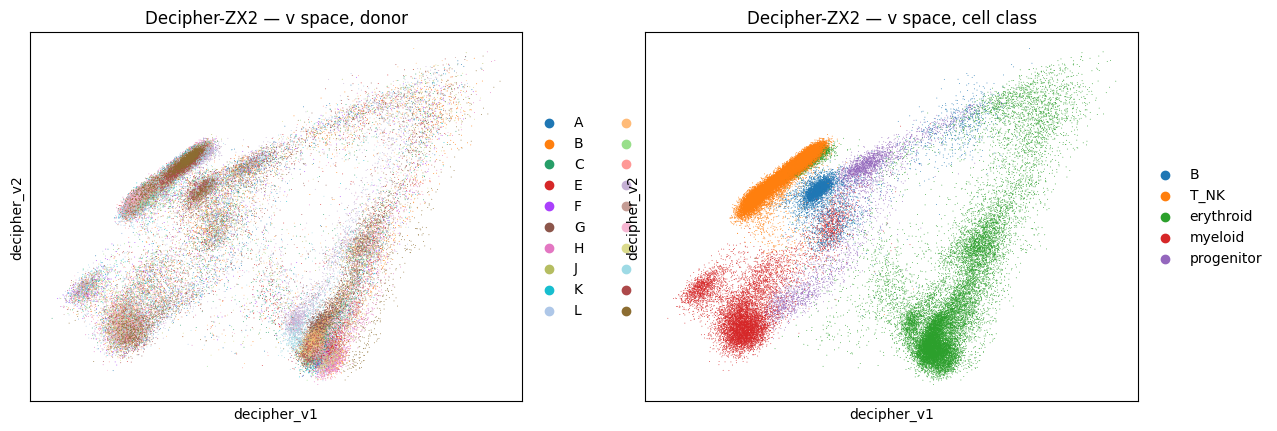

In [17]:
# V space -- the 2D Decipher space, plotted directly.
for name, a in arms.items():
    sc.pl.embedding(a, basis="decipher_v", color=[BATCH_KEY, "cell_class"], ncols=2,
                    title=[f"{name} — v space, donor", f"{name} — v space, cell class"])

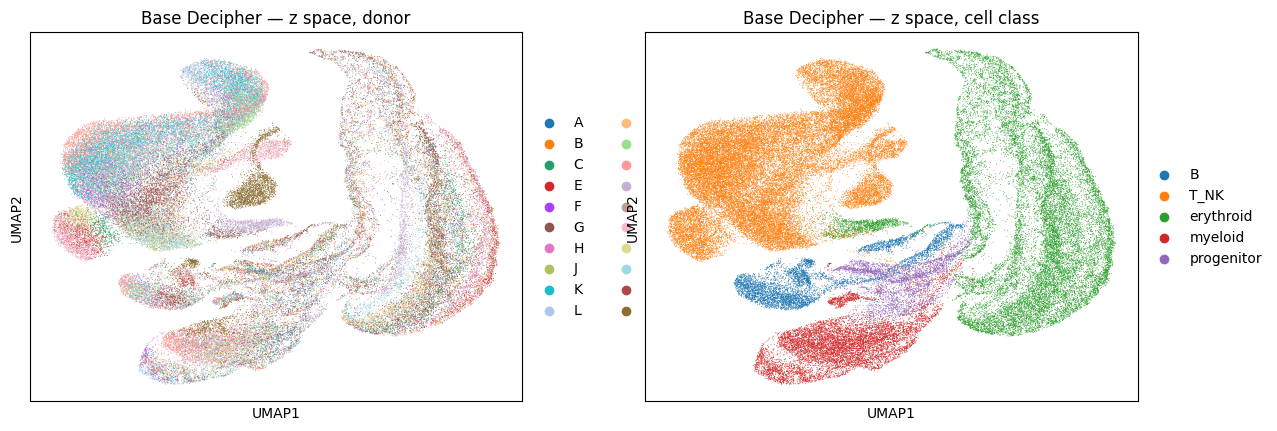

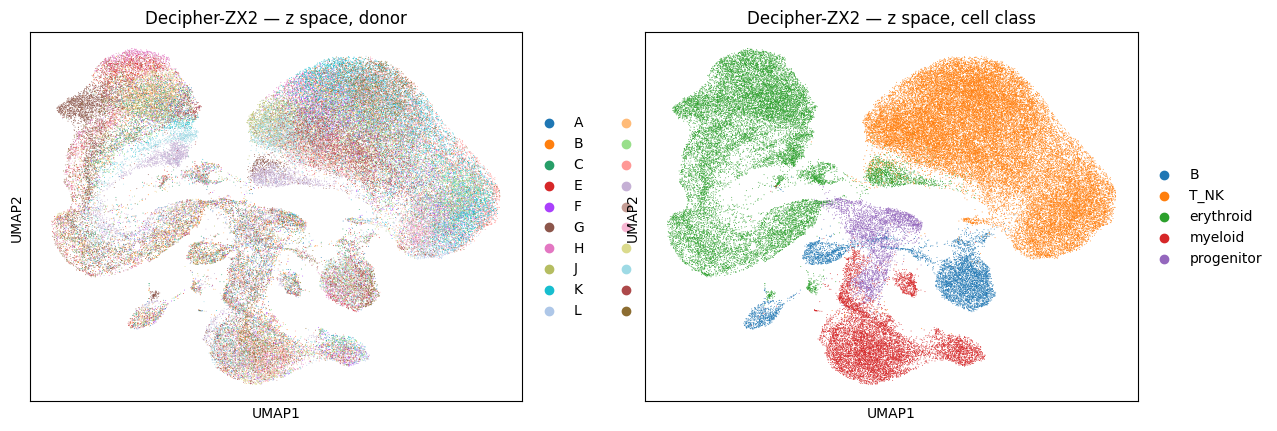

In [18]:
# Z space -- dim_z is 10, so build a neighbour graph on decipher_z and UMAP it,
# exactly as 9.9's plot_z_space did. ~2-4 min per arm at full scale.
for name, a in arms.items():
    sc.pp.neighbors(a, use_rep="decipher_z", key_added="dz", random_state=0)
    sc.tl.umap(a, neighbors_key="dz", random_state=0)
    sc.pl.umap(a, color=[BATCH_KEY, "cell_class"], ncols=2,
               title=[f"{name} — z space, donor", f"{name} — z space, cell class"])

In [19]:
# Batch silhouette. LOWER = donors better mixed. The X-space row is the "as given"
# reference: donor separation in the input, before any model touches it.
rows = [{
    "arm": "(input data)", "space": "X (log-norm PCA)",
    "sil_batch": silhouette_score(xs.obsm["X_pca"], batch_codes,
                                  sample_size=SIL_SAMPLE, random_state=0),
}]
for name, a in arms.items():
    for space in ["decipher_v", "decipher_z"]:
        rows.append({
            "arm": name, "space": space,
            "sil_batch": silhouette_score(a.obsm[space], batch_codes,
                                          sample_size=SIL_SAMPLE, random_state=0),
        })

sil = pd.DataFrame(rows)
sil["sil_batch"] = sil["sil_batch"].round(4)
print("batch silhouette (lower = donors better mixed)\n")
print(sil.to_string(index=False))

batch silhouette (lower = donors better mixed)

          arm            space  sil_batch
 (input data) X (log-norm PCA)    -0.1372
Base Decipher       decipher_v    -0.2461
Base Decipher       decipher_z    -0.2671
 Decipher-ZX2       decipher_v    -0.2744
 Decipher-ZX2       decipher_z    -0.2348


## 11. After training

**Run this kernel as `decipher-env` (Python 3.11.14).** It is the only one of the three
environments with `scib_metrics`, which the metrics below need. Preprocessing has been
verified to give identical results under `decipher-env` (scanpy 1.10.0) and `.venv`
(scanpy 1.11.5).

**The 9.9 metric code does not transfer unchanged.** `compute_integration_metrics` in
`Data Analysis/9.9 new_models_run.ipynb` does
`pd.qcut(adata.obs["latent_t"], q=n_bins)`, which needs a *continuous* ground-truth time.
There is none on real data. The fix is to drop the `qcut` and pass
`adata.obs["cell_class"].cat.codes` as `labels` directly — that column now exists, from
section 7. `ilisi_knn` needs no change; it only wants the batch codes.

```python
from scib_metrics import ilisi_knn, graph_connectivity, silhouette_batch
from scib_metrics.nearest_neighbors import pynndescent

neigh   = pynndescent(adata.obsm["decipher_v"], n_neighbors=30)
batches = adata.obs[BATCH_KEY].cat.codes.to_numpy()
labels  = adata.obs["cell_class"].cat.codes.to_numpy()   # replaces latent_t_bin

{"ilisi":      ilisi_knn(neigh, batches, scale=True),
 "graph_conn": graph_connectivity(neigh, labels=labels),
 "sil_batch":  silhouette_batch(adata.obsm["decipher_v"], labels=labels,
                                batch=batches, rescale=True)}
```

**There is still no ceiling.** The simulated sweeps compare against
`layers["counts_nobatch"]`; no such thing exists for real data, so you get relative
comparisons between the arms rather than distance-from-optimal. The nearest substitute is a
**floor**: re-run this notebook with `PRIMARY_ONLY = False` (it writes a separate
`..._all25.h5ad`, so nothing is overwritten) and measure batch separation between the
technical pairs C1/C2, S1/S2 and Sk1/Sk2. Same biological material, re-run, so whatever
separation survives there is purely technical.